In [1]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
from utils import check_group_holidays

In [4]:
sample_size = 25

In [5]:
current_dir = os.getcwd()

data_dir = "tech_challenge-data-us_flights_ml"

In [6]:
flights_csv = "flights.csv"
df_flights = pd.read_csv(os.path.join(current_dir, data_dir, flights_csv))

/tmp/ipykernel_42421/221509293.py:2: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flights = pd.read_csv(os.path.join(current_dir, data_dir, flights_csv))


In [7]:
df_flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24  CANCELLED

In [8]:
not_cancelled_mask = df_flights["CANCELLED"] == 0

df_flights.loc[not_cancelled_mask, "FLIGHT_SEQUENCE"] = (
    df_flights.loc[not_cancelled_mask, ["TAIL_NUMBER", "YEAR", "MONTH", "DAY", "SCHEDULED_DEPARTURE"]]
    .sort_values(by=["TAIL_NUMBER", "YEAR", "MONTH", "DAY", "SCHEDULED_DEPARTURE"])
    .groupby(["TAIL_NUMBER", "YEAR", "MONTH", "DAY"])
    .cumcount() + 1
)

df_flights["FLIGHT_SEQUENCE"] = df_flights["FLIGHT_SEQUENCE"].astype("Int64")

In [9]:
df_flights_considered = df_flights.loc[
    (df_flights["CANCELLED"] == 0) & (df_flights["DIVERTED"] == 0) & (df_flights["MONTH"] != 10),
    [
        "YEAR", "MONTH", "DAY", "DAY_OF_WEEK",
        "AIRLINE", "FLIGHT_NUMBER", "TAIL_NUMBER", "FLIGHT_SEQUENCE",
        "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "DISTANCE",
        "SCHEDULED_DEPARTURE", "SCHEDULED_ARRIVAL", "SCHEDULED_TIME",
        "ARRIVAL_DELAY"
    ]
]

In [10]:
del df_flights
gc.collect()

30

In [11]:
df_flights_considered["HOUR"] = df_flights_considered["SCHEDULED_DEPARTURE"] // 100

wd_mapping = {
    1: "MON",
    2: "TUE",
    3: "WED",
    4: "THU",
    5: "FRI",
    6: "SAT",
    7: "SUN",
}
df_flights_considered["DAY_OF_WEEK"] = pd.Categorical(
    df_flights_considered["DAY_OF_WEEK"],
    categories=wd_mapping.keys(),
    ordered=True
)
df_flights_considered["DAY_OF_WEEK_ABBR"] = df_flights_considered["DAY_OF_WEEK"].cat.rename_categories(wd_mapping)

df_flights_considered["ROUTE"] = df_flights_considered["ORIGIN_AIRPORT"].astype(str) + "-" + df_flights_considered["DESTINATION_AIRPORT"].astype(str)

tol_min = 15
df_flights_considered["DELAYED"] = df_flights_considered["ARRIVAL_DELAY"] >= tol_min

In [12]:
df_flights_considered.info()

<class 'pandas.DataFrame'>
Index: 5231130 entries, 0 to 5819078
Data columns (total 19 columns):
 #   Column               Dtype   
---  ------               -----   
 0   YEAR                 int64   
 1   MONTH                int64   
 2   DAY                  int64   
 3   DAY_OF_WEEK          category
 4   AIRLINE              str     
 5   FLIGHT_NUMBER        int64   
 6   TAIL_NUMBER          str     
 7   FLIGHT_SEQUENCE      Int64   
 8   ORIGIN_AIRPORT       object  
 9   DESTINATION_AIRPORT  object  
 10  DISTANCE             int64   
 11  SCHEDULED_DEPARTURE  int64   
 12  SCHEDULED_ARRIVAL    int64   
 13  SCHEDULED_TIME       float64 
 14  ARRIVAL_DELAY        float64 
 15  HOUR                 int64   
 16  DAY_OF_WEEK_ABBR     category
 17  ROUTE                str     
 18  DELAYED              bool    
dtypes: Int64(1), bool(1), category(2), float64(2), int64(8), object(2), str(3)
memory usage: 698.4+ MB


In [13]:
df_flights_considered.sample(n=sample_size)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,FLIGHT_SEQUENCE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL,SCHEDULED_TIME,ARRIVAL_DELAY,HOUR,DAY_OF_WEEK_ABBR,ROUTE,DELAYED
3947183,2015,9,2,3,WN,511,N392SW,5,HOU,CLT,920,1520,1840,140.0,74.0,15,WED,HOU-CLT,True
5444251,2015,12,7,1,WN,4096,N265WN,4,BWI,MDW,611,1815,1925,130.0,19.0,18,MON,BWI-MDW,True
2424359,2015,6,3,3,WN,724,N7703A,3,PHX,ONT,325,1005,1115,70.0,-9.0,10,WED,PHX-ONT,False
2131440,2015,5,15,5,DL,2095,N696DL,4,ATL,ORF,516,2158,2337,99.0,-17.0,21,FRI,ATL-ORF,False
1605563,2015,4,13,1,EV,3256,N29906,4,ORD,CAK,343,1409,1626,77.0,-5.0,14,MON,ORD-CAK,False
1810954,2015,4,26,7,EV,4339,N13124,1,IAH,HOB,501,1030,1109,99.0,-9.0,10,SUN,IAH-HOB,False
3442991,2015,8,3,1,WN,4634,N218WN,1,BWI,BUF,281,610,715,65.0,-4.0,6,MON,BWI-BUF,False
1695719,2015,4,19,7,DL,1552,N334NB,1,BOS,DTW,632,815,1026,131.0,-11.0,8,SUN,BOS-DTW,False
1512378,2015,4,7,2,EV,5263,N741EV,5,RIC,BOS,474,1730,1904,94.0,38.0,17,TUE,RIC-BOS,True
1713784,2015,4,20,1,US,1722,N749US,2,CLT,DCA,331,940,1105,85.0,62.0,9,MON,CLT-DCA,True


## Sampled dataset

In [14]:
rng = np.random.default_rng(seed=42)

n_rows, _ = df_flights_considered.shape
sampled_dataset_mask = np.zeros(n_rows, dtype=bool)

sampled_dataset_size = 100_000
sampled_dataset_indices = rng.choice(n_rows, size=sampled_dataset_size, replace=False)

sampled_dataset_mask[sampled_dataset_indices] = True

In [15]:
df_flights_sampled = df_flights_considered[sampled_dataset_mask].copy(deep=True)

In [16]:
df_flights_sampled.info()

<class 'pandas.DataFrame'>
Index: 100000 entries, 4 to 5819069
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   YEAR                 100000 non-null  int64   
 1   MONTH                100000 non-null  int64   
 2   DAY                  100000 non-null  int64   
 3   DAY_OF_WEEK          100000 non-null  category
 4   AIRLINE              100000 non-null  str     
 5   FLIGHT_NUMBER        100000 non-null  int64   
 6   TAIL_NUMBER          100000 non-null  str     
 7   FLIGHT_SEQUENCE      100000 non-null  Int64   
 8   ORIGIN_AIRPORT       100000 non-null  object  
 9   DESTINATION_AIRPORT  100000 non-null  object  
 10  DISTANCE             100000 non-null  int64   
 11  SCHEDULED_DEPARTURE  100000 non-null  int64   
 12  SCHEDULED_ARRIVAL    100000 non-null  int64   
 13  SCHEDULED_TIME       100000 non-null  float64 
 14  ARRIVAL_DELAY        100000 non-null  float64 
 15  HOUR           

In [17]:
df_flights_sampled.sample(n=sample_size)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,FLIGHT_SEQUENCE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL,SCHEDULED_TIME,ARRIVAL_DELAY,HOUR,DAY_OF_WEEK_ABBR,ROUTE,DELAYED
2126649,2015,5,15,5,EV,4088,N17159,5,ABQ,IAH,744,1640,1949,129.0,2.0,16,FRI,ABQ-IAH,False
647291,2015,2,12,4,UA,1610,N64809,3,TPA,EWR,997,1655,1935,160.0,38.0,16,THU,TPA-EWR,True
1707579,2015,4,19,7,WN,1785,N482WN,6,ATL,PIT,526,2015,2155,100.0,-16.0,20,SUN,ATL-PIT,False
531989,2015,2,5,4,DL,340,N539US,1,ATL,MSP,907,725,906,161.0,2.0,7,THU,ATL-MSP,False
5633877,2015,12,19,6,AS,814,N513AS,5,OGG,SAN,2541,2145,503,318.0,11.0,21,SAT,OGG-SAN,False
2378178,2015,5,31,7,B6,581,N373JB,4,JFK,HOU,1428,1428,1729,241.0,-17.0,14,SUN,JFK-HOU,False
5098658,2015,11,15,7,OO,5221,N728SK,2,IAH,TUS,936,1145,1328,163.0,3.0,11,SUN,IAH-TUS,False
3998012,2015,9,5,6,DL,1395,N919DL,2,ATL,ILM,377,1931,2047,76.0,6.0,19,SAT,ATL-ILM,False
3339083,2015,7,27,1,AA,1919,N114UW,6,CLT,MIA,650,2015,2217,122.0,6.0,20,MON,CLT-MIA,False
1566180,2015,4,10,5,EV,4473,N12924,8,ORD,TVC,224,2135,2342,67.0,122.0,21,FRI,ORD-TVC,True


In [18]:
df_flights_sampled["FLIGHT_SEQUENCE"] = df_flights_sampled["FLIGHT_SEQUENCE"].astype(int)
df_flights_sampled["ORIGIN_AIRPORT"] = df_flights_sampled["ORIGIN_AIRPORT"].astype(str)
df_flights_sampled["DESTINATION_AIRPORT"] = df_flights_sampled["DESTINATION_AIRPORT"].astype(str)
df_flights_sampled["SCHEDULED_TIME"] = df_flights_sampled["SCHEDULED_TIME"].astype(int)
df_flights_sampled["ARRIVAL_DELAY"] = df_flights_sampled["ARRIVAL_DELAY"].astype(int)

In [19]:
df_flights_considered["DELAYED"].value_counts(normalize=True)

DELAYED
False    0.808194
True     0.191806
Name: proportion, dtype: float64

In [20]:
df_flights_sampled["DELAYED"].value_counts(normalize=True)

DELAYED
False    0.80811
True     0.19189
Name: proportion, dtype: float64

In [21]:
plot_opts = dict(
    kind="bar",
    stacked=True,
    color=["deepskyblue", "gainsboro"],
)

<Axes: xlabel='MONTH'>

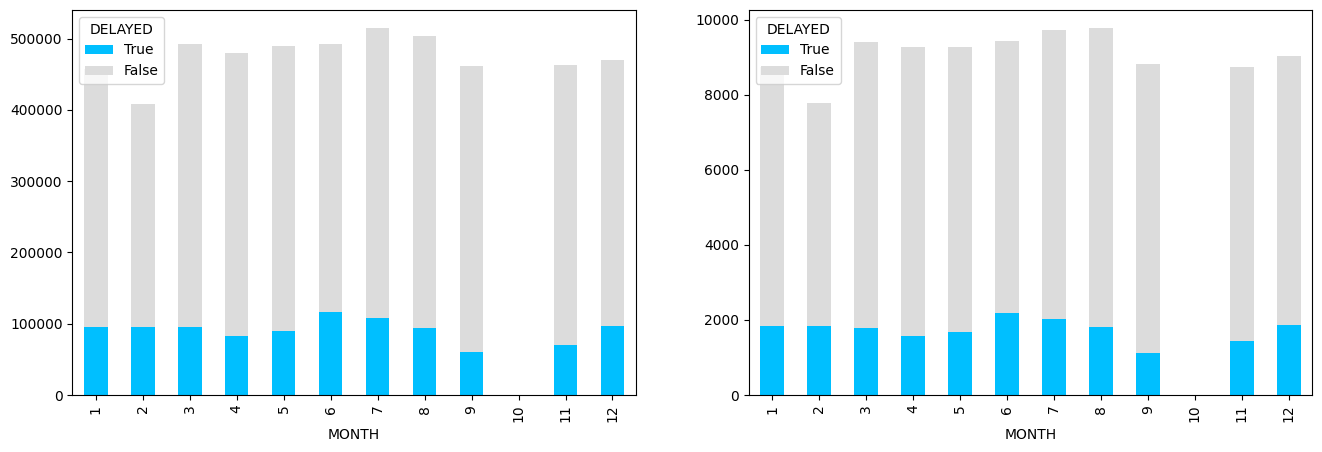

In [22]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

cols = ["MONTH", "DELAYED"]

df_flights_considered[cols].value_counts().unstack().reindex(range(1, 13), fill_value=0).iloc[:, [1, 0]].plot(**plot_opts, ax=axc)
df_flights_sampled[cols].value_counts().unstack().reindex(range(1, 13), fill_value=0).iloc[:, [1, 0]].plot(**plot_opts, ax=axs)

<Axes: xlabel='DAY'>

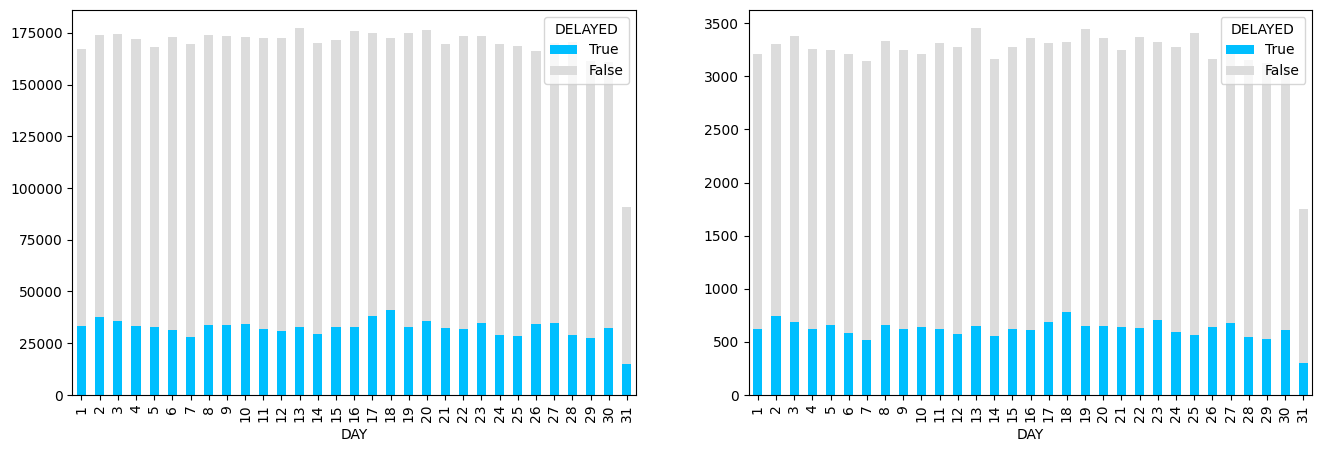

In [23]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

cols = ["DAY", "DELAYED"]

df_flights_considered[cols].value_counts().sort_index().unstack().iloc[:, [1, 0]].plot(**plot_opts, ax=axc)
df_flights_sampled[cols].value_counts().sort_index().unstack().iloc[:, [1, 0]].plot(**plot_opts, ax=axs)

<Axes: xlabel='DAY_OF_WEEK_ABBR'>

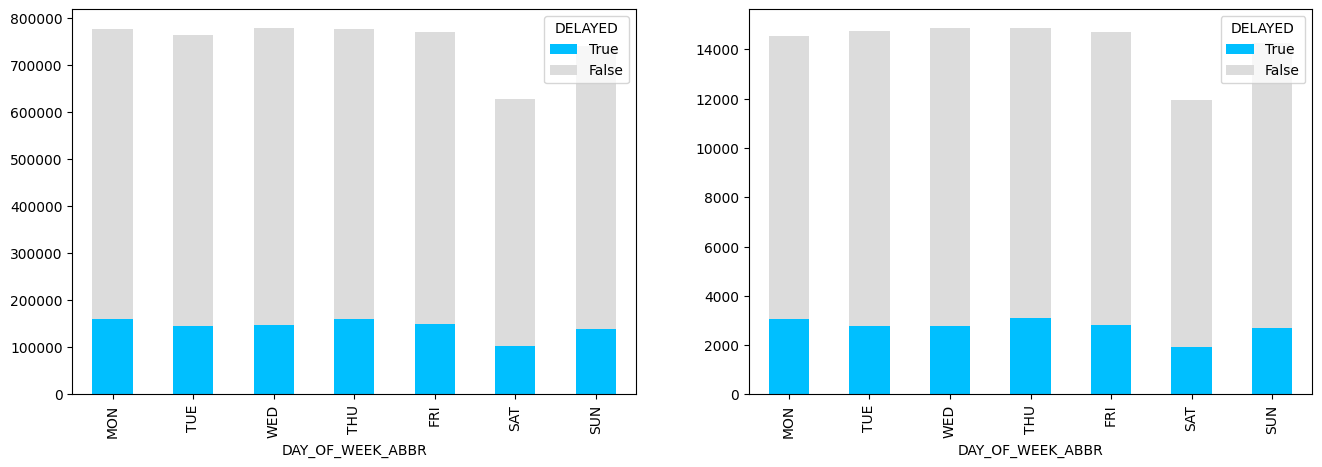

In [24]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

cols = ["DAY_OF_WEEK_ABBR", "DELAYED"]

df_flights_considered[cols].value_counts().sort_index().unstack().iloc[:, [1, 0]].plot(**plot_opts, ax=axc)
df_flights_sampled[cols].value_counts().sort_index().unstack().iloc[:, [1, 0]].plot(**plot_opts, ax=axs)

<Axes: xlabel='HOUR'>

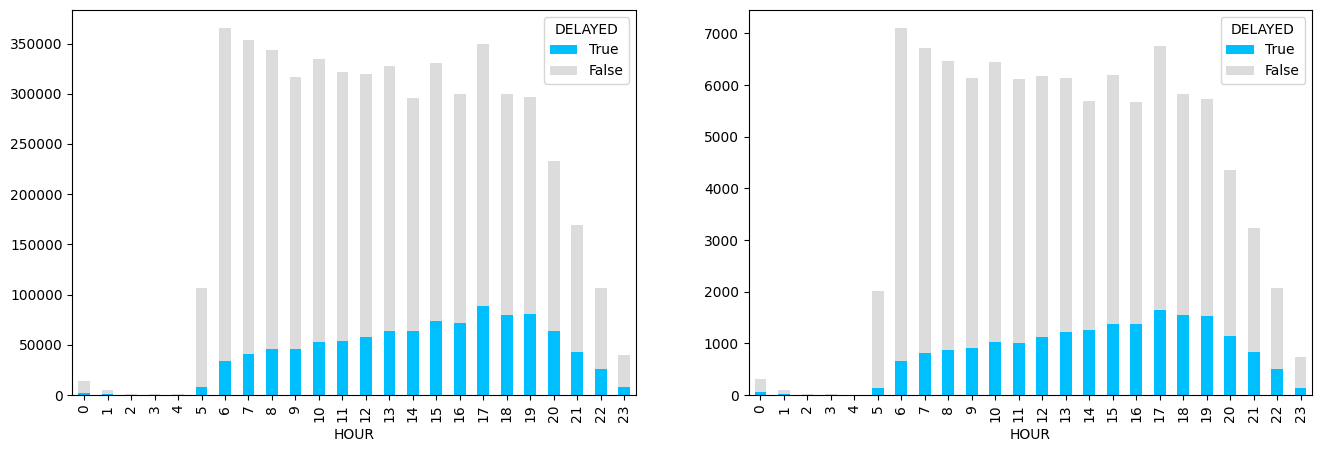

In [25]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

cols = ["HOUR", "DELAYED"]

df_flights_considered[cols].value_counts().sort_index().unstack().iloc[:, [1, 0]].plot(**plot_opts, ax=axc)
df_flights_sampled[cols].value_counts().sort_index().unstack().iloc[:, [1, 0]].plot(**plot_opts, ax=axs)

<Axes: xlabel='ORIGIN_AIRPORT'>

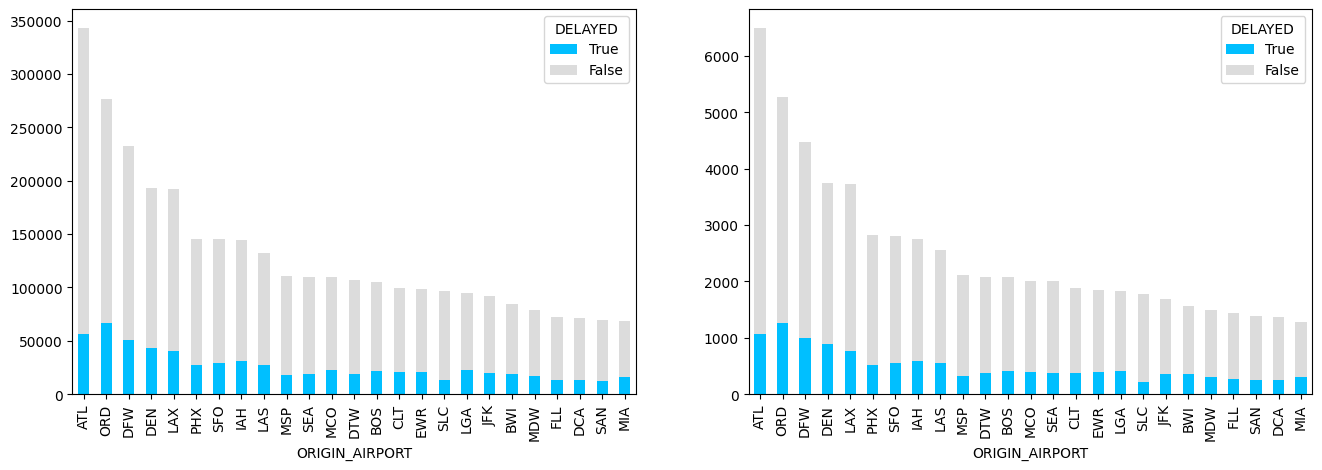

In [26]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

cols = ["ORIGIN_AIRPORT", "DELAYED"]

df_flights_considered[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts, ax=axc)
df_flights_sampled[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts, ax=axs)

<Axes: xlabel='DESTINATION_AIRPORT'>

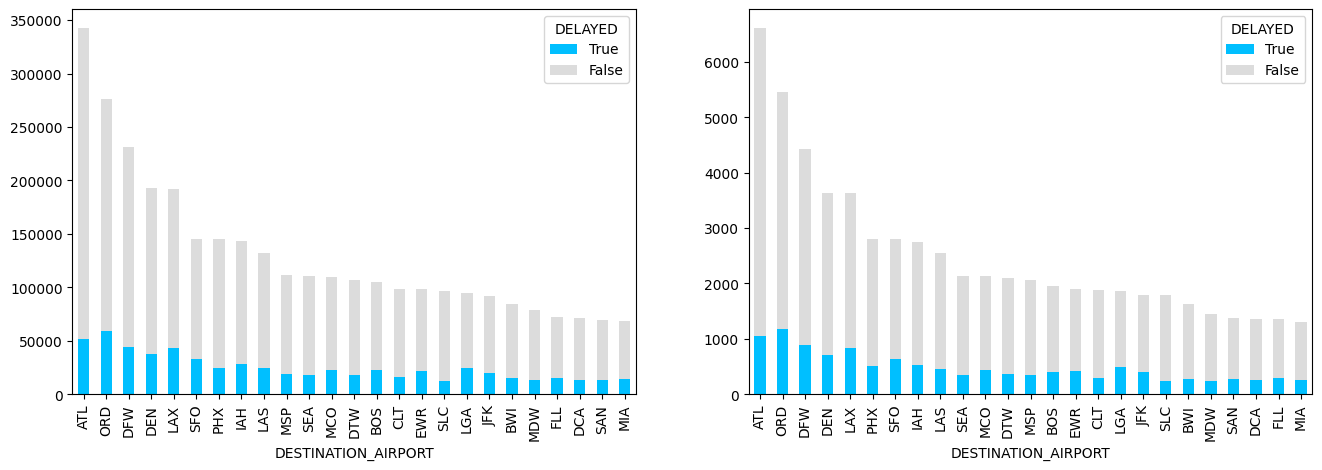

In [27]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

cols = ["DESTINATION_AIRPORT", "DELAYED"]

df_flights_considered[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts, ax=axc)
df_flights_sampled[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts, ax=axs)

<Axes: xlabel='ROUTE'>

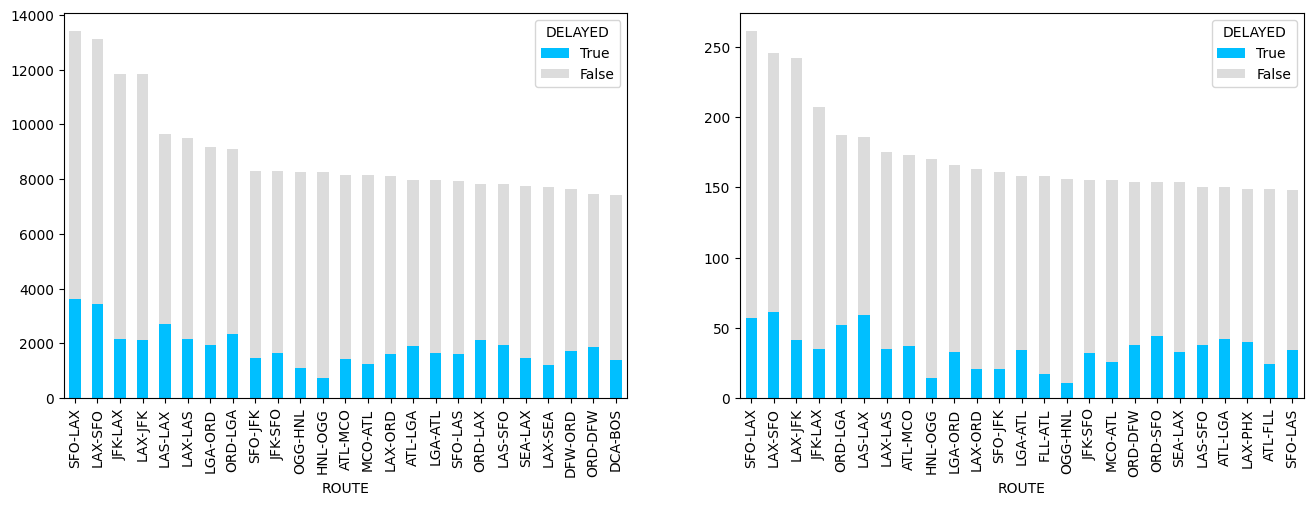

In [28]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

cols = ["ROUTE", "DELAYED"]

df_flights_considered[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts, ax=axc)
df_flights_sampled[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts, ax=axs)

<Axes: xlabel='AIRLINE'>

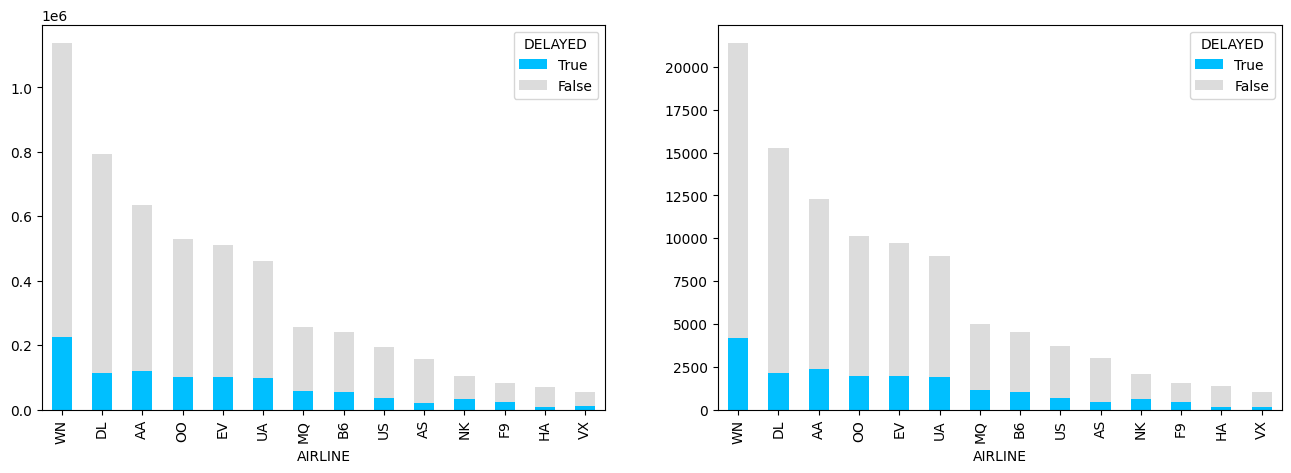

In [29]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

cols = ["AIRLINE", "DELAYED"]

df_flights_considered[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).iloc[:, [1, 0]].plot(**plot_opts, ax=axc)
df_flights_sampled[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).iloc[:, [1, 0]].plot(**plot_opts, ax=axs)

<Axes: xlabel='FLIGHT_NUMBER'>

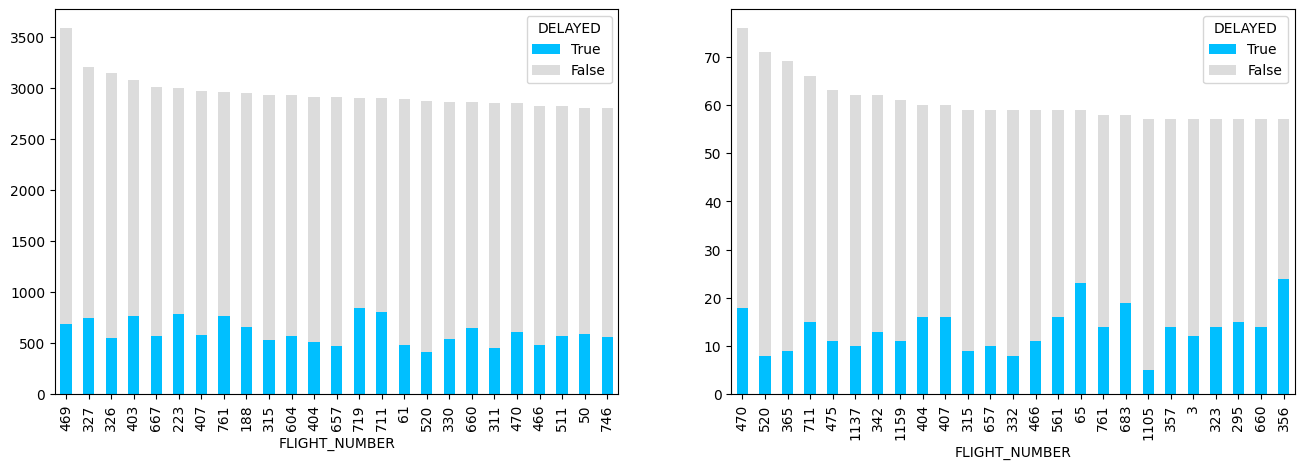

In [30]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

cols = ["FLIGHT_NUMBER", "DELAYED"]

df_flights_considered[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts, ax=axc)
df_flights_sampled[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts, ax=axs)

<Axes: xlabel='TAIL_NUMBER'>

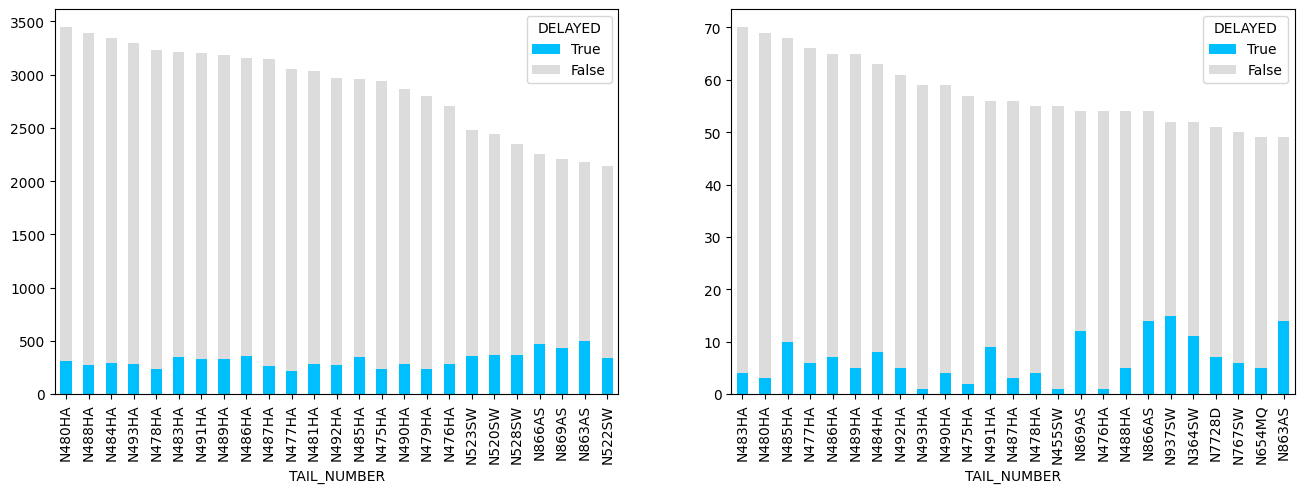

In [31]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

cols = ["TAIL_NUMBER", "DELAYED"]

df_flights_considered[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts, ax=axc)
df_flights_sampled[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts, ax=axs)

<Axes: xlabel='FLIGHT_SEQUENCE'>

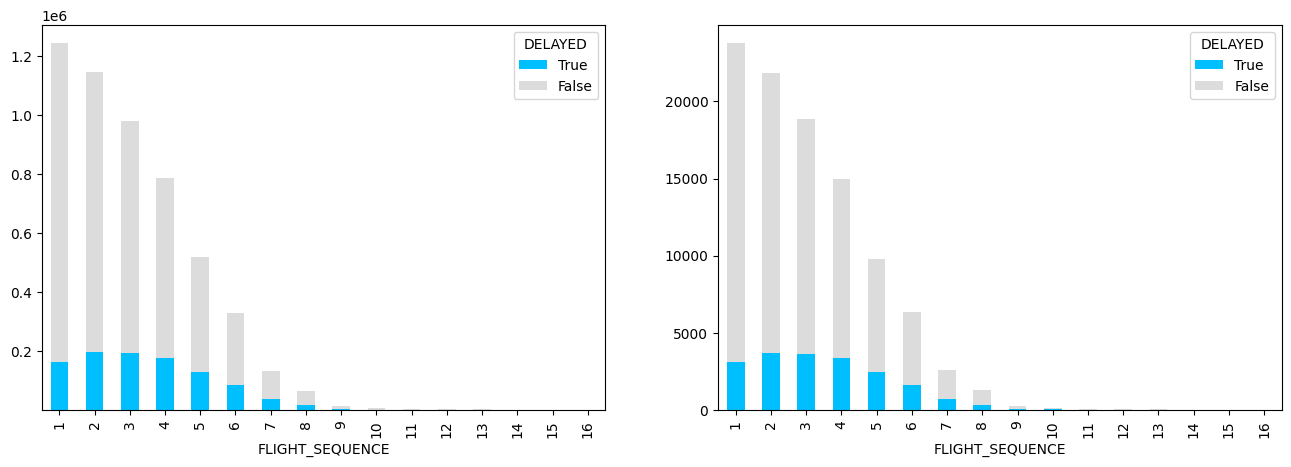

In [32]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

cols = ["FLIGHT_SEQUENCE", "DELAYED"]

df_flights_considered[cols].value_counts().sort_index().unstack().iloc[:, [1, 0]].plot(**plot_opts, ax=axc)
df_flights_sampled[cols].value_counts().sort_index().unstack().iloc[:, [1, 0]].plot(**plot_opts, ax=axs)

<Axes: ylabel='Frequency'>

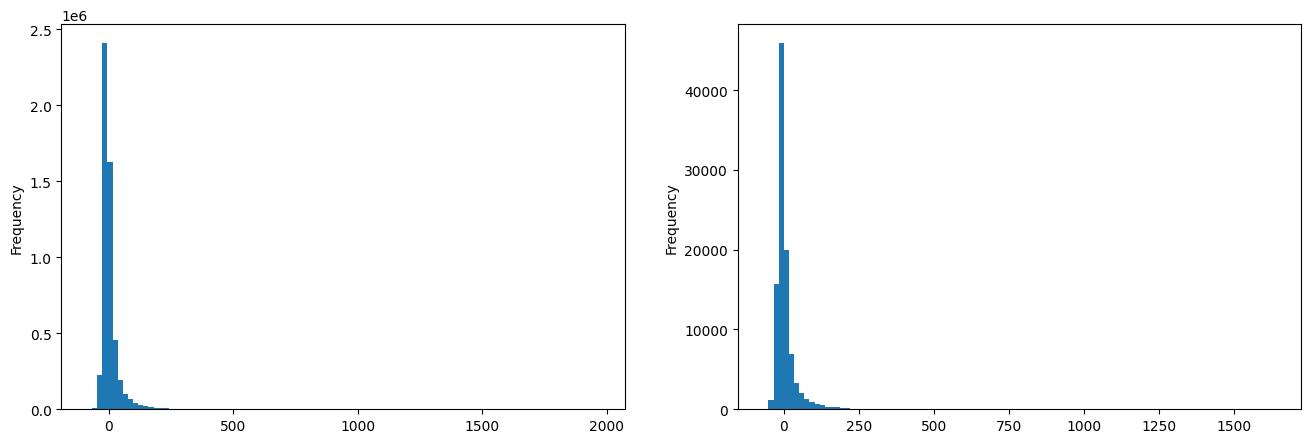

In [33]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

df_flights_considered["ARRIVAL_DELAY"].plot(kind="hist", bins=100, ax=axc)
df_flights_sampled["ARRIVAL_DELAY"].plot(kind="hist", bins=100, ax=axs)

<Axes: xlabel='DISTANCE', ylabel='ARRIVAL_DELAY'>

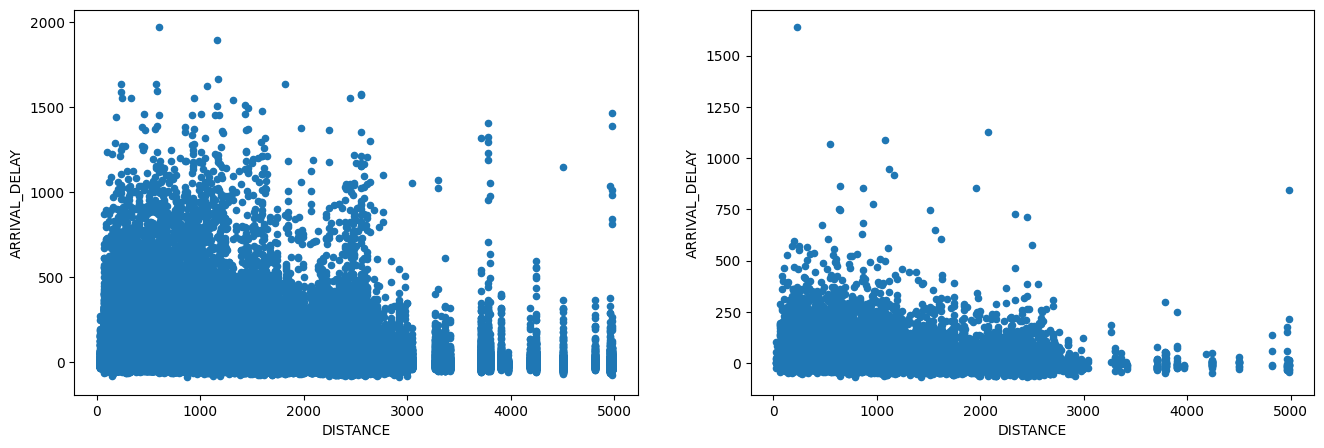

In [34]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

cols = [
    x := "DISTANCE",
    y := "ARRIVAL_DELAY",
]

df_flights_considered[cols].plot(kind="scatter", x=x, y=y, ax=axc)
df_flights_sampled[cols].plot(kind="scatter", x=x, y=y, ax=axs)

<Axes: xlabel='SCHEDULED_TIME', ylabel='ARRIVAL_DELAY'>

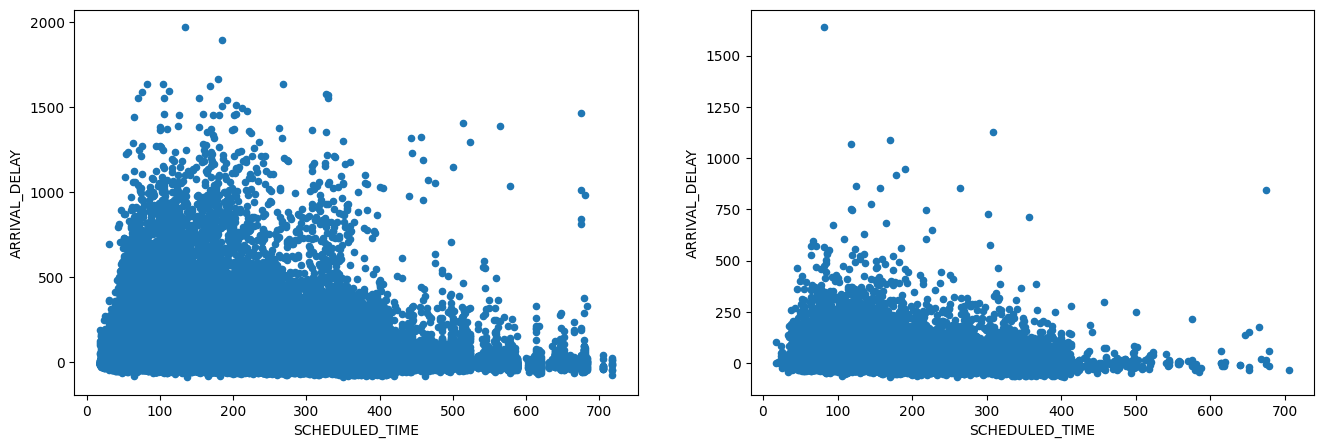

In [35]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

cols = [
    x := "SCHEDULED_TIME",
    y := "ARRIVAL_DELAY",
]

df_flights_considered[cols].plot(kind="scatter", x=x, y=y, ax=axc)
df_flights_sampled[cols].plot(kind="scatter", x=x, y=y, ax=axs)

In [36]:
del df_flights_considered
gc.collect()

56

## Enriquecimento e variáveis derivadas

In [37]:
airports_csv = "airports.csv"
df_airports = pd.read_csv(os.path.join(current_dir, data_dir, airports_csv))

In [38]:
df_airports.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  322 non-null    str    
 1   AIRPORT    322 non-null    str    
 2   CITY       322 non-null    str    
 3   STATE      322 non-null    str    
 4   COUNTRY    322 non-null    str    
 5   LATITUDE   319 non-null    float64
 6   LONGITUDE  319 non-null    float64
dtypes: float64(2), str(5)
memory usage: 17.7 KB


In [39]:
df_airports.sample(n=sample_size)

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
117,FSM,Fort Smith Regional Airport,Fort Smith,AR,USA,35.33659,-94.36744
88,DIK,Dickinson Theodore Roosevelt Regional Airport,Dickinson,ND,USA,46.79739,-102.80195
295,STT,Cyril E. King Airport,Charlotte Amalie,VI,USA,18.33731,-64.97336
49,BUF,Buffalo Niagara International Airport,Buffalo,NY,USA,42.94052,-78.73217
174,LAS,McCarran International Airport,Las Vegas,NV,USA,36.08036,-115.15233
162,ITO,Hilo International Airport,Hilo,HI,USA,19.72026,-155.04847
115,FNT,Bishop International Airport,Flint,MI,USA,42.96550,-83.74346
36,BMI,Central Illinois Regional Airport at Bloomingt...,Bloomington,IL,USA,40.47799,-88.91595
143,HOU,William P. Hobby Airport,Houston,TX,USA,29.64542,-95.27889
105,EWN,Coastal Carolina Regional Airport (Craven Coun...,New Bern,NC,USA,35.07297,-77.04294


In [40]:
airports_cols = ["IATA_CODE", "CITY", "STATE", "COUNTRY", "LATITUDE", "LONGITUDE"]

origin_airport_cols = {c: "ORIGIN_" + c for c in airports_cols[1:]}
destination_airport_cols = {c: "DESTINATION_" + c for c in airports_cols[1:]}

df_flights_sampled = df_flights_sampled.merge(
    right=df_airports[airports_cols].rename(columns={"IATA_CODE": "ORIGIN_AIRPORT", **origin_airport_cols}),
    how="left",
    on="ORIGIN_AIRPORT",
    validate="many_to_one"
).merge(
    right=df_airports[airports_cols].rename(columns={"IATA_CODE": "DESTINATION_AIRPORT", **destination_airport_cols}),
    how="left",
    on="DESTINATION_AIRPORT",
    validate="many_to_one"
)

In [41]:
df_flights_sampled["DT_SCHEDULED_DEPARTURE"] = pd.to_datetime(df_flights_sampled[["YEAR", "MONTH", "DAY"]], format="%Y-%m-%d")

df_flights_sampled = (
    df_flights_sampled
    .groupby(["ORIGIN_COUNTRY", "ORIGIN_STATE"], group_keys=True)
    .apply(check_group_holidays)
    .reset_index(level=[0, 1], drop=False)
    .rename(columns={"HOLIDAY": "HOLIDAY_ORIGIN", "HOLIDAY_EVE": "HOLIDAY_EVE_ORIGIN"})
)

df_flights_sampled = (
    df_flights_sampled
    .groupby(["DESTINATION_COUNTRY", "DESTINATION_STATE"], group_keys=True)
    .apply(check_group_holidays)
    .reset_index(level=[0, 1], drop=False)
    .rename(columns={"HOLIDAY": "HOLIDAY_DESTINATION", "HOLIDAY_EVE": "HOLIDAY_EVE_DESTINATION"})
)

In [42]:
df_flights_sampled["DEPARTURE_ACC_MINUTES"] = (df_flights_sampled["SCHEDULED_DEPARTURE"] // 100) * 60 + (df_flights_sampled["SCHEDULED_DEPARTURE"] % 100)

df_flights_sampled["ARRIVAL_ACC_MINUTES"] = (df_flights_sampled["SCHEDULED_ARRIVAL"] // 100) * 60 + (df_flights_sampled["SCHEDULED_ARRIVAL"] % 100)

In [43]:
km_to_miles_const = 0.621371

dist_cat_bins = [
    0,
    1000 * km_to_miles_const,
    3000 * km_to_miles_const,
    np.inf,
]

dist_cat_labels = [
    "Short Distance",
    "Medium Distance",
    "Long Distance",
]

df_flights_sampled["DISTANCE_CATEGORY"] = pd.cut(
    df_flights_sampled["DISTANCE"],
    bins=dist_cat_bins,
    right=False,
    labels=dist_cat_labels,
    ordered=True
)

In [44]:
sch_time_cat_bins = [
    0,
    1 * 60,
    3 * 60,
    5 * 60,
    np.inf,
]

sch_time_cat_labels = [
    "Short Duration",
    "Medium Duration",
    "Long Duration",
    "Very Long Duration",
]

df_flights_sampled["SCHEDULED_TIME_CATEGORY"] = pd.cut(
    df_flights_sampled["SCHEDULED_TIME"],
    bins=sch_time_cat_bins,
    right=False,
    labels=sch_time_cat_labels,
    ordered=True
)

## Limpeza

In [45]:
df_flights_sampled["ORIGIN_COUNTRY"].unique()

<StringArray>
['USA']
Length: 1, dtype: str

In [46]:
df_flights_sampled["DESTINATION_COUNTRY"].unique()

<StringArray>
['USA']
Length: 1, dtype: str

In [47]:
df_flights_sampled.drop(
    columns=[
        "YEAR", "DAY_OF_WEEK_ABBR", "SCHEDULED_DEPARTURE", "DT_SCHEDULED_DEPARTURE", "SCHEDULED_ARRIVAL",
        "FLIGHT_NUMBER", "TAIL_NUMBER",
        "ORIGIN_COUNTRY", "DESTINATION_COUNTRY",
        "DELAYED",
    ],
    inplace=True
)

In [48]:
df_flights_sampled.info()

<class 'pandas.DataFrame'>
Index: 100000 entries, 573 to 8198
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   DESTINATION_STATE        100000 non-null  str     
 1   ORIGIN_STATE             100000 non-null  str     
 2   MONTH                    100000 non-null  int64   
 3   DAY                      100000 non-null  int64   
 4   DAY_OF_WEEK              100000 non-null  category
 5   AIRLINE                  100000 non-null  str     
 6   FLIGHT_SEQUENCE          100000 non-null  int64   
 7   ORIGIN_AIRPORT           100000 non-null  str     
 8   DESTINATION_AIRPORT      100000 non-null  str     
 9   DISTANCE                 100000 non-null  int64   
 10  SCHEDULED_TIME           100000 non-null  int64   
 11  ARRIVAL_DELAY            100000 non-null  int64   
 12  HOUR                     100000 non-null  int64   
 13  ROUTE                    100000 non-null  str     
 14  ORIG

In [49]:
df_flights_sampled.sample(n=sample_size)

,DESTINATION_STATE,ORIGIN_STATE,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_SEQUENCE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_TIME,ARRIVAL_DELAY,HOUR,ROUTE,ORIGIN_CITY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_CITY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE,HOLIDAY_ORIGIN,HOLIDAY_EVE_ORIGIN,HOLIDAY_DESTINATION,HOLIDAY_EVE_DESTINATION,DEPARTURE_ACC_MINUTES,ARRIVAL_ACC_MINUTES,DISTANCE_CATEGORY,SCHEDULED_TIME_CATEGORY
92015,NJ,NY,12,4,5,EV,3,BUF,EWR,282,84,-5,11,BUF-EWR,Buffalo,42.94052,-78.73217,Newark,40.69250,-74.16866,False,False,False,False,678,762,Short Distance,Medium Duration
87094,IL,CO,11,17,2,AA,3,DEN,ORD,888,151,18,10,DEN-ORD,Denver,39.85841,-104.66700,Chicago,41.97960,-87.90446,False,False,False,False,610,821,Medium Distance,Medium Duration
69090,MN,ND,8,18,2,OO,1,GFK,MSP,284,73,-9,8,GFK-MSP,Grand Forks,47.94926,-97.17611,Minneapolis,44.88055,-93.21692,False,False,False,False,480,553,Short Distance,Medium Duration
18742,CA,OR,3,8,7,AS,3,PDX,LAX,834,143,91,17,PDX-LAX,Portland,45.58872,-122.59750,Los Angeles,33.94254,-118.40807,False,False,False,False,1075,1218,Medium Distance,Medium Duration
46483,MI,IL,6,7,7,EV,6,ORD,GRR,137,58,7,16,ORD-GRR,Chicago,41.97960,-87.90446,Grand Rapids,42.88082,-85.52277,False,False,False,False,970,1088,Short Distance,Short Duration
98038,NY,NY,12,25,5,B6,1,JFK,BUF,301,89,72,8,JFK-BUF,New York,40.63975,-73.77893,Buffalo,42.94052,-78.73217,True,False,True,False,480,569,Short Distance,Medium Duration
79973,PA,MA,9,23,3,AA,2,BOS,PHL,280,90,7,9,BOS-PHL,Boston,42.36435,-71.00518,Philadelphia,39.87195,-75.24114,False,False,False,False,570,660,Short Distance,Medium Duration
78926,VA,NC,9,19,6,AA,4,CLT,DCA,331,78,-9,17,CLT-DCA,Charlotte,35.21401,-80.94313,Arlington,38.85208,-77.03772,False,False,False,False,1075,1153,Short Distance,Medium Duration
66729,IL,RI,8,10,1,WN,4,PVD,MDW,842,155,74,17,PVD-MDW,Providence,41.72400,-71.42822,Chicago,41.78598,-87.75242,True,False,False,False,1025,1120,Medium Distance,Medium Duration
98153,CA,HI,12,25,5,UA,3,HNL,SFO,2398,300,114,13,HNL-SFO,Honolulu,21.31869,-157.92241,San Francisco,37.61900,-122.37484,True,False,True,False,835,1255,Long Distance,Very Long Duration


In [50]:
u_cat_cols = [
    "AIRLINE",
    "ORIGIN_AIRPORT", "ORIGIN_CITY", "ORIGIN_STATE",
    "DESTINATION_AIRPORT", "DESTINATION_CITY", "DESTINATION_STATE",
    "ROUTE",
]

df_flights_sampled[u_cat_cols] = df_flights_sampled[u_cat_cols].astype("category")

In [51]:
df_flights_sampled["MONTH"] = pd.Categorical(
    df_flights_sampled["MONTH"],
    categories=list(range(1, 13)),
    ordered=True
)

df_flights_sampled["DAY"] = pd.Categorical(
    df_flights_sampled["DAY"],
    categories=list(range(1, 32)),
    ordered=True
)

df_flights_sampled["HOUR"] = pd.Categorical(
    df_flights_sampled["HOUR"],
    categories=list(range(0, 24)),
    ordered=True
)

In [52]:
df_flights_sampled.info()

<class 'pandas.DataFrame'>
Index: 100000 entries, 573 to 8198
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   DESTINATION_STATE        100000 non-null  category
 1   ORIGIN_STATE             100000 non-null  category
 2   MONTH                    100000 non-null  category
 3   DAY                      100000 non-null  category
 4   DAY_OF_WEEK              100000 non-null  category
 5   AIRLINE                  100000 non-null  category
 6   FLIGHT_SEQUENCE          100000 non-null  int64   
 7   ORIGIN_AIRPORT           100000 non-null  category
 8   DESTINATION_AIRPORT      100000 non-null  category
 9   DISTANCE                 100000 non-null  int64   
 10  SCHEDULED_TIME           100000 non-null  int64   
 11  ARRIVAL_DELAY            100000 non-null  int64   
 12  HOUR                     100000 non-null  category
 13  ROUTE                    100000 non-null  category
 14  ORIG

## Carga

In [53]:
flights_sampled_parquet = "flights_sampled.parquet"
df_flights_sampled.to_parquet(os.path.join(current_dir, flights_sampled_parquet), engine="fastparquet", index=False)